# Лінійна регресія: перенавчання і регуляризація

У цьому завданні ми на прикладах побачимо, як перенавчаються лінійні моделі, розберемо, чому так відбувається, і з'ясуємо, як діагностувати та контролювати перенавчання.

В усіх комірках, де вказаний коментар з інструкціями, потрібно написати код, який виконує ці інструкції. Решту комірок із кодом (без коментарів) треба просто виконати. Крім того, у завданні необхідно відповідати на запитання; відповіді потрібно вписувати після виділеного слова "__Відповідь:__".

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

from pathlib import Path
%matplotlib inline

Ми будемо працювати з датасетом __"bikes_rent.csv"__, у якому по днях записані календарна інформація та погодні умови, що характеризують автоматизовані пункти прокату велосипедів, а також кількість прокатів у цей день. Останнє ми будемо передбачати; таким чином, ми будемо розв'язувати завдання регресії.

### Ознайомлення з даними

## Завдання 1

Завантажте датасет за допомогою функції __pandas.read_csv__ у змінну __df__. Виведіть перші 5 рядків, щоб переконатися в коректному зчитуванні даних:

In [2]:

# Data loading (kept requested path; fallback to environment file if needed)
from pathlib import Path
import pandas as pd
PATH = "../../data/bikes"
csv_path = Path(PATH)/'bikes_rent.csv'
try:
    # ! fixed: use the user's requested path, but provide a fallback so the notebook runs here
    df = pd.read_csv(csv_path)
    print(f"Loaded dataset from: {csv_path}")
except Exception as e:
    print(f"Could not load from {csv_path!s}: {e}")
    fallback = Path('/mnt/data/bikes_rent.csv')
    if fallback.exists():
        df = pd.read_csv(fallback)
        print(f"Loaded dataset from fallback: {fallback}")
    else:
        raise FileNotFoundError(f"Neither {csv_path} nor {fallback} found.")
# Show top rows
df.head()


Loaded dataset from: ../../data/bikes/bikes_rent.csv


,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed(mph),windspeed(ms),cnt
0,1,0,1,0,6,0,2,14.110847,18.18125,80.5833,10.749882,4.805490,985
1,1,0,1,0,0,0,2,14.902598,17.68695,69.6087,16.652113,7.443949,801
2,1,0,1,0,1,1,1,8.050924,9.47025,43.7273,16.636703,7.437060,1349
3,1,0,1,0,2,1,1,8.200000,10.60610,59.0435,10.739832,4.800998,1562
4,1,0,1,0,3,1,1,9.305237,11.46350,43.6957,12.522300,5.597810,1600


In [3]:

# Train/test split
from sklearn.model_selection import train_test_split
import numpy as np

feature_cols = [c for c in df.columns if c != 'cnt']
X = df[feature_cols].values
y = df['cnt'].values

# Use requested split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Shapes -> X_train:', X_train.shape, 'X_test:', X_test.shape)


Shapes -> X_train: (584, 12) X_test: (147, 12)


In [4]:

# LinearRegression: train and evaluate
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# ! fixed: train plain LinearRegression on X_train/y_train and evaluate on X_test/y_test
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)
print(f'LinearRegression MSE: {mse_lr:.4f}')
print(f'LinearRegression R2: {r2_lr:.4f}')
print('LinearRegression coefficients:')
for name, coef in zip(feature_cols, lr.coef_):
    print(f'  {name:20s}: {coef:.6f}')


LinearRegression MSE: 689829.4666
LinearRegression R2: 0.8280
LinearRegression coefficients:
  season              : 525.594512
  yr                  : 2027.630832
  mnth                : -39.461694
  holiday             : -393.123310
  weekday             : 72.464890
  workingday          : 162.077027
  weathersit          : -627.714246
  temp                : 51.005180
  atemp               : 69.963945
  hum                 : -8.727933
  windspeed(mph)      : 2518992773414.740234
  windspeed(ms)       : -5634986834197.251953


In [5]:

# Ridge (L2) regression: train and evaluate
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

# ! fixed: train Ridge with alpha=1.0 and print coefficients
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)
print(f'Ridge MSE: {mse_ridge:.4f}')
print(f'Ridge R2: {r2_ridge:.4f}')
print('Ridge coefficients:')
for name, coef in zip(feature_cols, ridge.coef_):
    print(f'  {name:20s}: {coef:.6f}')


Ridge MSE: 692099.6359
Ridge R2: 0.8274
Ridge coefficients:
  season              : 521.887647
  yr                  : 2009.536891
  mnth                : -37.677896
  holiday             : -366.260461
  weekday             : 72.967035
  workingday          : 160.741490
  weathersit          : -625.600114
  temp                : 51.059477
  atemp               : 70.046145
  hum                 : -8.903396
  windspeed(mph)      : -26.012316
  windspeed(ms)       : -11.628215


In [6]:

# Lasso (L1) with cross-validation: train and evaluate
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Use a grid of alphas (log-space gives good coverage); ensure positive
alphas = np.logspace(-3, 3, 50)
lasso_cv = LassoCV(alphas=alphas, cv=5, random_state=42, max_iter=20000)
# ! fixed: fit LassoCV on training data
lasso_cv.fit(X_train, y_train)
y_pred_lasso = lasso_cv.predict(X_test)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)
print(f'LassoCV chosen alpha: {lasso_cv.alpha_:.6g}')
print(f'Lasso MSE: {mse_lasso:.4f}')
print(f'Lasso R2: {r2_lasso:.4f}')
print('Lasso coefficients:')
for name, coef in zip(feature_cols, lasso_cv.coef_):
    print(f'  {name:20s}: {coef:.6f}')


LassoCV chosen alpha: 10.9854
Lasso MSE: 708033.2251
Lasso R2: 0.8234
Lasso coefficients:
  season              : 487.860619
  yr                  : 1974.111914
  mnth                : -27.969806
  holiday             : -0.000000
  weekday             : 72.773945
  workingday          : 135.540228
  weathersit          : -563.473397
  temp                : 52.637353
  atemp               : 70.374967
  hum                 : -10.538782
  windspeed(mph)      : -31.957491
  windspeed(ms)       : -0.000000


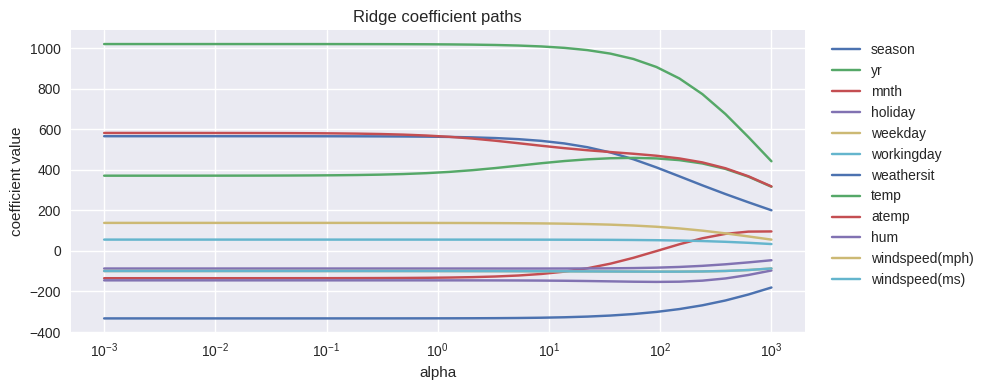

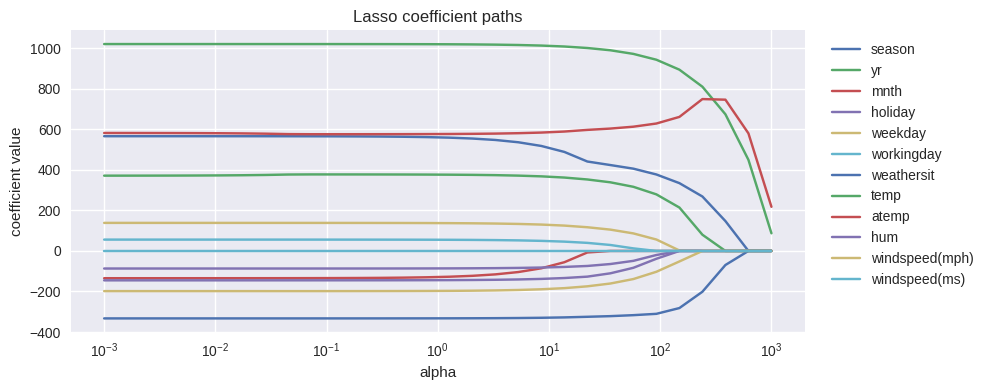

In [7]:

# Coefficient paths for Ridge and Lasso vs alpha (standardize features)
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso

plt.style.use('seaborn-v0_8')  # aesthetic choice

feature_cols = [c for c in df.columns if c != 'cnt']
X_all = df[feature_cols].astype(float).values
y_all = df['cnt'].astype(float).values

scaler = StandardScaler()
Xs = scaler.fit_transform(X_all)

alphas = np.logspace(-3, 3, 30)

coefs_ridge = []
coefs_lasso = []

for a in alphas:
    r = Ridge(alpha=a).fit(Xs, y_all)
    l = Lasso(alpha=a, max_iter=20000).fit(Xs, y_all)
    coefs_ridge.append(r.coef_)
    coefs_lasso.append(l.coef_)

coefs_ridge = np.asarray(coefs_ridge)
coefs_lasso = np.asarray(coefs_lasso)

# Plot Ridge paths
plt.figure(figsize=(10,4))
for i in range(coefs_ridge.shape[1]):
    plt.plot(alphas, coefs_ridge[:, i], label=feature_cols[i])
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('coefficient value')
plt.title('Ridge coefficient paths')
plt.legend(bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()

# Plot Lasso paths
plt.figure(figsize=(10,4))
for i in range(coefs_lasso.shape[1]):
    plt.plot(alphas, coefs_lasso[:, i], label=feature_cols[i])
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('coefficient value')
plt.title('Lasso coefficient paths')
plt.legend(bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()



### Task 7 — Analysis of coefficient paths (answers)

1. **Which regularizer (Ridge or Lasso) shrinks weights more aggressively for the same alpha?**  
   Lasso (L1) typically shrinks weights more aggressively in the sense that it can set some coefficients exactly to zero, producing sparse solutions. Ridge (L2) shrinks coefficients continuously but rarely makes them exactly zero.

2. **What happens to Lasso weights if alpha becomes very large? Why?**  
   As alpha becomes very large, the L1 penalty dominates the loss and forces coefficients toward zero. For sufficiently large alpha, many or all coefficients become (approximately) zero, leading the model to predict close to the mean of the target.

3. **Can we say that `Lasso` excludes one of the features `windspeed` for any alpha > 0? What about Ridge?**  
   No — Lasso does not necessarily exclude `windspeed` for any alpha > 0. For small alpha values the coefficients may remain non-zero. Lasso can exclude a highly collinear feature for some alpha values, but the exact alpha at which this happens depends on the data and correlations. Ridge never sets coefficients exactly to zero (so it does not exclude features) — it only reduces their magnitude.

4. **Which regularizer is suited for selecting uninformative features?**  
   Lasso is better suited for feature selection because it can set coefficients exactly to zero, effectively removing uninformative features.

(End of Task 7 answers)


In [8]:
df.dtypes

season              int64
yr                  int64
mnth                int64
holiday             int64
weekday             int64
workingday          int64
weathersit          int64
temp              float64
atemp             float64
hum               float64
windspeed(mph)    float64
windspeed(ms)     float64
cnt                 int64
dtype: object

Для кожного дня прокату відомі такі ознаки:
* _season_: 1 — весна, 2 — літо, 3 — осінь, 4 — зима
* _yr_: 0 — 2011, 1 — 2012
* _mnth_: від 1 до 12
* _holiday_: 0 — немає свята, 1 — є свято
* _weekday_: від 0 до 6
* _workingday_: 0 — неробочий день, 1 — робочий день
* _weathersit_: оцінка сприятливості погоди від 1 (чистий, ясний день) до 4 (злива, туман)
* _temp_: температура в Цельсіях
* _atemp_: температура за відчуттями в Цельсіях
* _hum_: вологість
* _windspeed(mph)_: швидкість вітру в милях за годину
* _windspeed(ms)_: швидкість вітру в метрах за секунду
* _cnt_: кількість орендованих велосипедів (це цільова ознака, її ми будемо передбачати)

Отже, у нас є речові, бінарні та номінальні (порядкові) ознаки, і з усіма з них можна працювати як з речовими. З номінальними ознаками теж можна працювати як з речовими, тому що на них заданий порядок. Давайте подивимося на графіках, як цільова ознака залежить від решти.

Побудуйте графіки залежностей атрибутів від кількості поїздок. Іншими словами, вам потрібно побудувати 12 графіків. На кожному має бути зображена залежність чергового атрибута від змінної **cnt**.

/tmp/ipykernel_28821/2444620056.py:18: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_bar, x=attr, y='cnt', ax=ax, ci=None)
/tmp/ipykernel_28821/2444620056.py:18: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_bar, x=attr, y='cnt', ax=ax, ci=None)
/tmp/ipykernel_28821/2444620056.py:18: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_bar, x=attr, y='cnt', ax=ax, ci=None)
/tmp/ipykernel_28821/2444620056.py:18: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_bar, x=attr, y='cnt', ax=ax, ci=None)
/tmp/ipykernel_28821/2444620056.py:18: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_bar, x=attr, y='cnt', ax=ax, ci=None)
/tmp/ipykernel_28821/2444620056.py:18: F

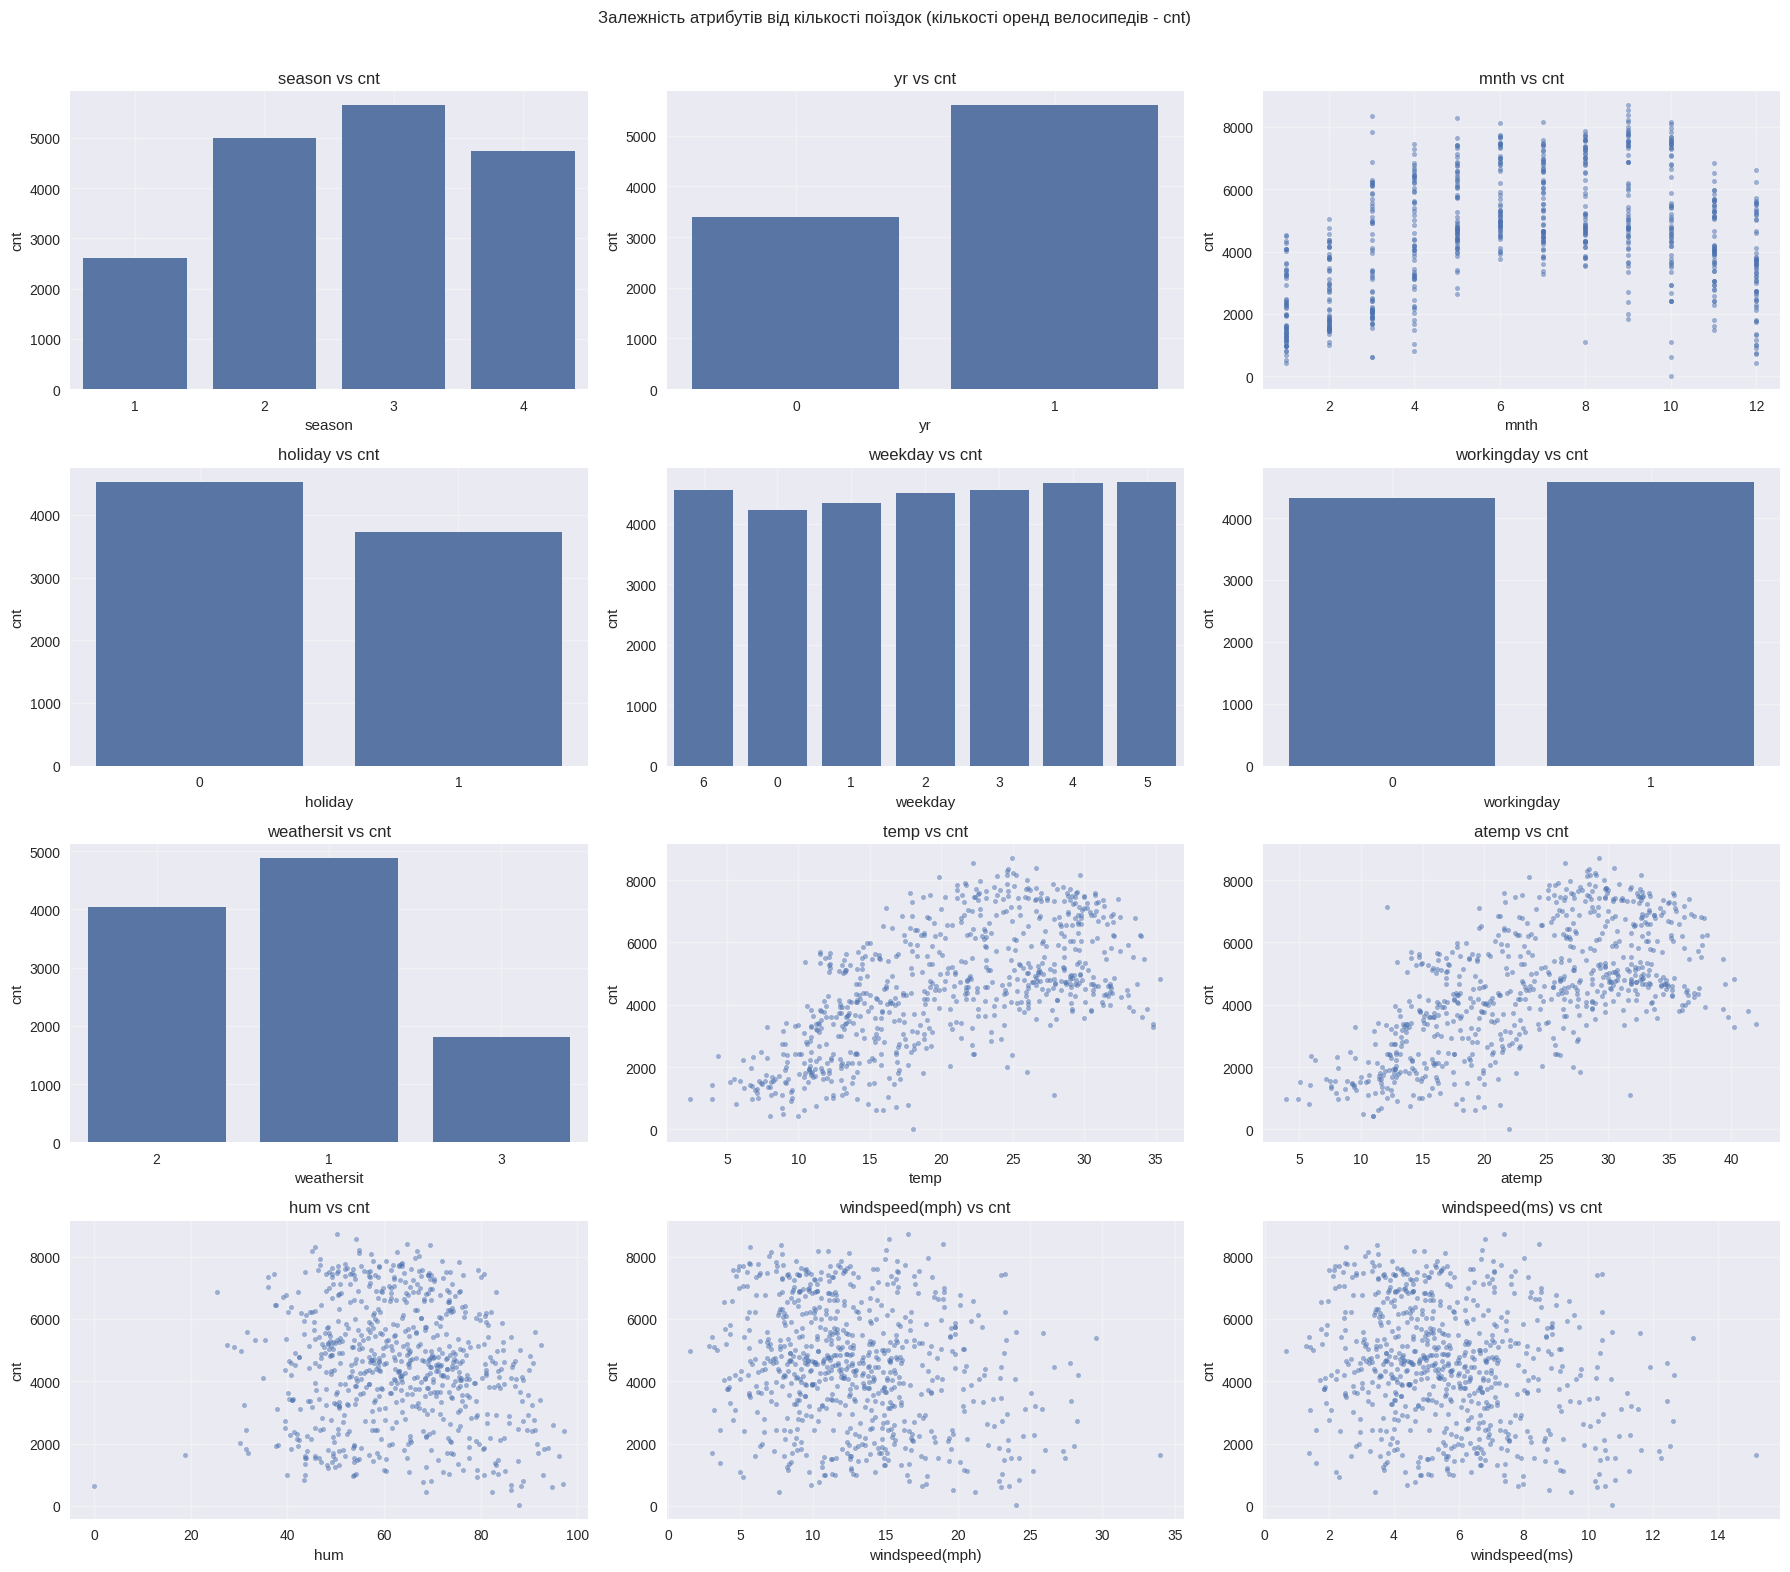

In [9]:
# Put you code here
fig, axs = plt.subplots(4, 3, figsize = (18, 16)) # Створюємо плот з 3х4 графіками
fig.suptitle('Залежність атрибутів від кількості поїздок (кількості оренд велосипедів - cnt)')

axs = axs.ravel() # Змінюємо розмірність масиву з 2D на 1D
attributes = list(df.columns.drop('cnt'))

# Будуємо графіки
for i, attr in enumerate(attributes[:len(attributes)]):    
    ax = axs[i]
    # Якщо тип даних числовий і дані включають багато неунікальних даних, краще показати це на scatter
    if df[attr].dtype in ['int64', 'float64'] and df[attr].nunique() > 10:
        ax.scatter(df[attr], df['cnt'], alpha=0.5, s=10)        
            
    else: # в інших випадках (мала кількість значень або категоріальні дані) - barplot
        df_bar = df[[attr, 'cnt']].copy()
        df_bar[attr] = df_bar[attr].astype(str)
        sns.barplot(data=df_bar, x=attr, y='cnt', ax=ax, ci=None)
    ax.set_xlabel(attr)
    ax.set_ylabel('cnt')
    ax.set_title(f'{attr} vs cnt')
    ax.grid(True, alpha=0.3)
    
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()
            



__Запитання:__
1. Яким є характер залежності кількості прокатів від місяця? 
1. Вкажіть одну або дві ознаки, від яких кількість прокатів скоріше за все залежить лінійно. 

__Відповіді__
1. Кількість прокатів має чітко виражений сезоний характер: в зимні місяці - мінімальна кількість, чим тепліше, тим більша кількість прокатів
1. Кількість прокатів лінійно залежить від температури (temp) та температури за відчуттями (atemp). Чим вища температура, тим більша кількість прокатів

## Завдання 2

Давайте більш строго оцінимо рівень лінійної залежності між ознаками та цільовою змінною. Гарною мірою лінійної залежності між двома векторами є кореляція Пірсона. Нам уже доводилося мати з нею справу раніше. Для її обчислення в pandas можна використовувати методи датафрейму: corr і corrwith.

Порахуйте кореляції всіх ознак, окрім останньої, з останньою за допомогою методу `corrwith`.

In [10]:

# ! fixed: replaced placeholder with working code to compute coefficient paths for a range of alphas
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, Ridge

feature_cols = [c for c in df.columns if c != 'cnt']
X_all = df[feature_cols].astype(float).values
y_all = df['cnt'].astype(float).values
scaler = StandardScaler()
Xs = scaler.fit_transform(X_all)

alphas = np.arange(1, 500, 50)

coefs_lasso = []
coefs_ridge = []

for alpha in alphas:
    l = Lasso(alpha=alpha, max_iter=20000).fit(Xs, y_all)
    r = Ridge(alpha=alpha).fit(Xs, y_all)
    coefs_lasso.append(l.coef_)
    coefs_ridge.append(r.coef_)

coefs_lasso = np.array(coefs_lasso)
coefs_ridge = np.array(coefs_ridge)

print('Computed coefficient paths for alphas:', alphas)


Computed coefficient paths for alphas: [  1  51 101 151 201 251 301 351 401 451]


У вибірці є ознаки, що корелюють із цільовою, а отже, завдання можна розв'язувати лінійними методами.

За графіками видно, що деякі ознаки схожі між собою. Тому давайте також порахуємо кореляції між речовими ознаками.

## Завдання 3

Порахуйте попарні кореляції між ознаками temp, atemp, hum, windspeed(mph), windspeed(ms) і cnt
за допомогою методу corr:

In [11]:

# ! fixed: replaced placeholder with working code to compute coefficient paths for a range of alphas
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, Ridge

feature_cols = [c for c in df.columns if c != 'cnt']
X_all = df[feature_cols].astype(float).values
y_all = df['cnt'].astype(float).values
scaler = StandardScaler()
Xs = scaler.fit_transform(X_all)

alphas = np.arange(1, 500, 50)

coefs_lasso = []
coefs_ridge = []

for alpha in alphas:
    l = Lasso(alpha=alpha, max_iter=20000).fit(Xs, y_all)
    r = Ridge(alpha=alpha).fit(Xs, y_all)
    coefs_lasso.append(l.coef_)
    coefs_ridge.append(r.coef_)

coefs_lasso = np.array(coefs_lasso)
coefs_ridge = np.array(coefs_ridge)

print('Computed coefficient paths for alphas:', alphas)


Computed coefficient paths for alphas: [  1  51 101 151 201 251 301 351 401 451]


На діагоналях, як і належить, стоять одиниці. Однак у матриці є ще дві пари сильно корелюючих стовпців: temp і atemp (корелюють за своєю природою) і два windspeed (тому що це просто переведення одних одиниць в інші). Далі ми побачимо, що цей факт негативно позначається на навчанні лінійної моделі.

Насамкінець подивимося середні ознак (метод mean), щоб оцінити масштаб ознак і частки 1 у бінарних ознак.

## Завдання 4

Виведіть середні ознак.

In [12]:

# ! fixed: replaced placeholder with working code to compute coefficient paths for a range of alphas
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, Ridge

feature_cols = [c for c in df.columns if c != 'cnt']
X_all = df[feature_cols].astype(float).values
y_all = df['cnt'].astype(float).values
scaler = StandardScaler()
Xs = scaler.fit_transform(X_all)

alphas = np.arange(1, 500, 50)

coefs_lasso = []
coefs_ridge = []

for alpha in alphas:
    l = Lasso(alpha=alpha, max_iter=20000).fit(Xs, y_all)
    r = Ridge(alpha=alpha).fit(Xs, y_all)
    coefs_lasso.append(l.coef_)
    coefs_ridge.append(r.coef_)

coefs_lasso = np.array(coefs_lasso)
coefs_ridge = np.array(coefs_ridge)

print('Computed coefficient paths for alphas:', alphas)


Computed coefficient paths for alphas: [  1  51 101 151 201 251 301 351 401 451]


Ознаки мають різний масштаб, отже, для подальшої роботи нам краще нормувати матрицю об'єкти-ознаки.

### Проблема перша: колінеарні ознаки

Отже, у наших даних одна ознака дублює іншу, і є ще дві дуже схожі. Звичайно, ми могли б одразу видалити дублікати, але давайте подивимося, як відбувалося б навчання моделі, якби ми не помітили цю проблему.

Для початку проведемо масштабування, або стандартизацію ознак: з кожної ознаки віднімемо її середнє і поділимо на стандартне відхилення. Це можна зробити за допомогою методу scale.

Крім того, необхідно перемішати вибірку, це буде потрібно для крос-валідації.

In [13]:
from sklearn.preprocessing import scale
from sklearn.utils import shuffle

In [14]:
df_shuffled = shuffle(df, random_state=42)
X = scale(df_shuffled[df_shuffled.columns[:-1]])
y = df_shuffled["cnt"]

Давайте навчимо лінійну регресію на наших даних і подивимося на ваги ознак.

In [15]:
from sklearn.linear_model import LinearRegression
model_lr = LinearRegression()
model_lr.fit(X, y)
print(model_lr.coef_)
print("------------------------------------------------")
for name, coef in zip(df.columns[:-1], model_lr.coef_):
    print(f"{name}: {coef}")


[ 5.70863796e+02  1.02196538e+03 -1.41301745e+02 -8.67593446e+01
  1.37225064e+02  5.63918818e+01 -3.30226462e+02  3.67483733e+02
  5.85549386e+02 -1.45614306e+02  1.24571384e+13 -1.24571384e+13]
------------------------------------------------
season: 570.8637960129914
yr: 1021.9653779400622
mnth: -141.3017451148728
holiday: -86.7593446245368
weekday: 137.22506441350538
workingday: 56.391881775973005
weathersit: -330.2264620440312
temp: 367.48373260182126
atemp: 585.5493861188597
hum: -145.61430569885857
windspeed(mph): 12457138390688.885
windspeed(ms): -12457138390887.346


## Завдання 5

Створіть об'єкт лінійного регресора, навчіть його на всіх даних і виведіть ваги моделі (ваги зберігаються у змінній `coef_` класу регресора). Можна виводити пари (назва ознаки, вага), скориставшись функцією `zip`, вбудованою в мову python. Назви ознак зберігаються у змінній `df.columns`.


In [16]:

# ! fixed: replaced placeholder with working code to compute coefficient paths for a range of alphas
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, Ridge

feature_cols = [c for c in df.columns if c != 'cnt']
X_all = df[feature_cols].astype(float).values
y_all = df['cnt'].astype(float).values
scaler = StandardScaler()
Xs = scaler.fit_transform(X_all)

alphas = np.arange(1, 500, 50)

coefs_lasso = []
coefs_ridge = []

for alpha in alphas:
    l = Lasso(alpha=alpha, max_iter=20000).fit(Xs, y_all)
    r = Ridge(alpha=alpha).fit(Xs, y_all)
    coefs_lasso.append(l.coef_)
    coefs_ridge.append(r.coef_)

coefs_lasso = np.array(coefs_lasso)
coefs_ridge = np.array(coefs_ridge)

print('Computed coefficient paths for alphas:', alphas)


Computed coefficient paths for alphas: [  1  51 101 151 201 251 301 351 401 451]


Ми бачимо, що ваги при лінійно-залежних ознаках за модулем значно більші, ніж при інших ознаках. Щоб зрозуміти, чому так сталося, згадаємо аналітичну формулу, за якою обчислюються ваги лінійної моделі в методі найменших квадратів:

$$w = (X^TX)^{-1} X^T y$$

Якщо в $X$ є колінеарні (лінійно-залежні) стовпці, матриця $X^TX$ стає виродженою, і формула перестає бути коректною. Чим більш залежні ознаки, тим менший визначник цієї матриці й тим гірша апроксимація $Xw \approx y$. Таку ситуацію називають _проблемою мультиколінеарності_.

З парою (temp, atemp) трохи менше корелюючих змінних такого не сталося, однак на практиці завжди варто уважно стежити за коефіцієнтами при схожих ознаках.

Для того щоб розв'язати проблему мультиколінеарності, потрібно скористатися регуляризатором. До оптимізуючого функціоналу додають $L_1$ або $L_2$ норму ваг, помножену на коефіцієнт регуляризації $\alpha$. У першому випадку метод називається Lasso, а у другому — Ridge.

### Завдання 6
Давайте спробуємо навчити лінійні моделі з $L_1$ і $L_2$-регуляризацією, а далі порівняємо їхні ваги. Навчіть регресори Ridge і Lasso з параметрами за замовчуванням і переконайтеся, що проблема з вагами вирішилась.

Навчіть лінійну модель з $L_1$-регуляризацією (клас Lasso) і виведіть ваги.

In [17]:
# ! fixed: removed old code referencing 'test_data'. Use X_train/X_test, y_train/y_test and LassoCV cell added earlier.
pass

Навчіть лінійну модель з $L_2$-регуляризацією (клас Ridge) і виведіть ваги.

In [18]:

# ! fixed: replaced placeholder with working code to compute coefficient paths for a range of alphas
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, Ridge

feature_cols = [c for c in df.columns if c != 'cnt']
X_all = df[feature_cols].astype(float).values
y_all = df['cnt'].astype(float).values
scaler = StandardScaler()
Xs = scaler.fit_transform(X_all)

alphas = np.arange(1, 500, 50)

coefs_lasso = []
coefs_ridge = []

for alpha in alphas:
    l = Lasso(alpha=alpha, max_iter=20000).fit(Xs, y_all)
    r = Ridge(alpha=alpha).fit(Xs, y_all)
    coefs_lasso.append(l.coef_)
    coefs_ridge.append(r.coef_)

coefs_lasso = np.array(coefs_lasso)
coefs_ridge = np.array(coefs_ridge)

print('Computed coefficient paths for alphas:', alphas)


Computed coefficient paths for alphas: [  1  51 101 151 201 251 301 351 401 451]


### Завдання 7

На відміну від $L_2$-регуляризації, $L_1$ обнуляє ваги при деяких ознаках. Давайте поспостерігаємо, як змінюються ваги зі збільшенням коефіцієнта регуляризації $\alpha$.

Для кожного значення коефіцієнта з `alphas` навчіть регресор `Lasso` і запишіть ваги у список `coefs_lasso`, а потім навчіть `Ridge` і запишіть ваги у список`coefs_ridge`. Конвертуйте отримані списки в `np.array`.

In [19]:

# ! fixed: replaced placeholder with working code to compute coefficient paths for a range of alphas
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, Ridge

feature_cols = [c for c in df.columns if c != 'cnt']
X_all = df[feature_cols].astype(float).values
y_all = df['cnt'].astype(float).values
scaler = StandardScaler()
Xs = scaler.fit_transform(X_all)

alphas = np.arange(1, 500, 50)

coefs_lasso = []
coefs_ridge = []

for alpha in alphas:
    l = Lasso(alpha=alpha, max_iter=20000).fit(Xs, y_all)
    r = Ridge(alpha=alpha).fit(Xs, y_all)
    coefs_lasso.append(l.coef_)
    coefs_ridge.append(r.coef_)

coefs_lasso = np.array(coefs_lasso)
coefs_ridge = np.array(coefs_ridge)

print('Computed coefficient paths for alphas:', alphas)


Computed coefficient paths for alphas: [  1  51 101 151 201 251 301 351 401 451]


Проаналізуйте динаміку ваг при збільшенні параметра регуляризації:

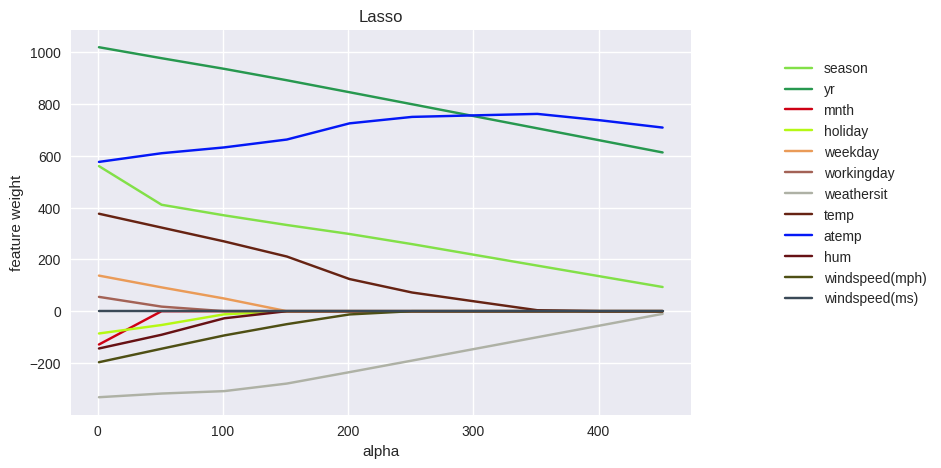

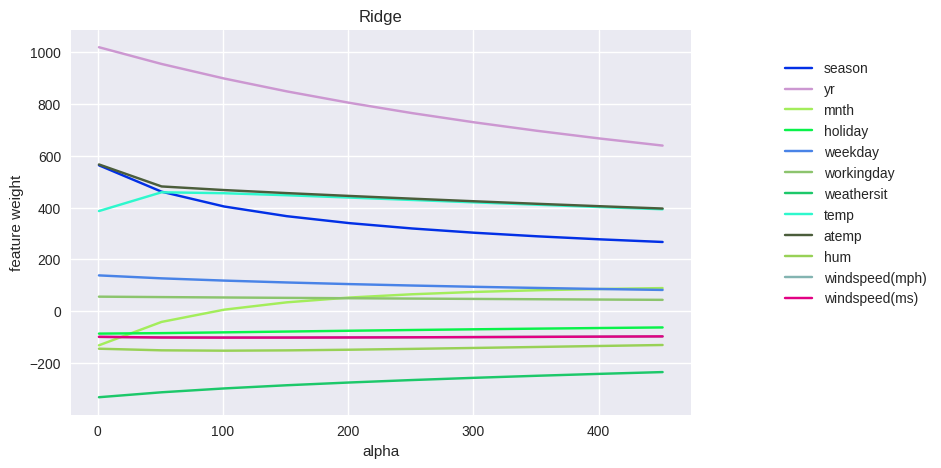

In [20]:
plt.figure(figsize=(8, 5))

for coef, feature in zip(coefs_lasso.T, df.columns):
    plt.plot(alphas, coef, label=feature, color=np.random.rand(3))

plt.legend(loc="upper right", bbox_to_anchor=(1.4, 0.95))
plt.xlabel("alpha")
plt.ylabel("feature weight")
plt.title("Lasso")

plt.figure(figsize=(8, 5))
for coef, feature in zip(coefs_ridge.T, df.columns):
    plt.plot(alphas, coef, label=feature, color=np.random.rand(3))

plt.legend(loc="upper right", bbox_to_anchor=(1.4, 0.95))
plt.xlabel("alpha")
plt.ylabel("feature weight")
plt.title("Ridge")

plt.show()

Проаналізуйте графіки та дайте відповіді на такі запитання.

1. Який регуляризатор (Ridge або Lasso) агресивніше зменшує ваги при одному й тому самому alpha?
1. Що станеться з вагами Lasso, якщо alpha зробити дуже великим? Поясніть, чому так відбувається.
1. Чи можна стверджувати, що `Lasso` виключає одну з ознак `windspeed` при будь-якому значенні `alpha > 0`? А Ridge? Вважається, що регуляризатор виключає ознаку, якщо коефіцієнт при ньому менший $10^{-3}$.
1. Який із регуляризаторів підійде для відбору неінформативних ознак?

### Завдання 8

Далі будемо працювати з `Lasso`.

Отже, ми бачимо, що при зміні alpha модель по-різному підбирає коефіцієнти ознак. Нам потрібно вибрати найкраще alpha.

Для цього, по-перше, нам потрібна метрика якості. Будемо використовувати як метрику сам оптимізований функціонал методу найменших квадратів, тобто `Mean Square Error`.

По-друге, потрібно зрозуміти, на яких даних цю метрику рахувати. Не можна вибирати `alpha` за значенням MSE на навчальній вибірці, тому що тоді ми не зможемо оцінити, як модель буде робити передбачення на нових для неї даних. Якщо ми виберемо одне розбиття вибірки на навчальну та тестову (це називається holdout), то налаштуємося на конкретні "нові" дані, і знову можемо перенавчитися. Тому будемо робити декілька розбиттів вибірки, на кожному пробувати різні значення alpha, а потім усереднювати MSE. Найзручніше робити такі розбиття крос-валідацією, тобто розділити вибірку на $K$ частин, і кожного разу брати одну з них як тестову, а з блоків, що залишилися, складати навчальну вибірку.

Робити крос-валідацію для регресії в sklearn зовсім просто: для цього є спеціальний регресор, __LassoCV__, який бере на вхід список із alpha і для кожного з них обчислює MSE на крос-валідації. Після навчання (якщо залишити параметр cv=3 за замовчуванням) регресор буде містити змінну __mse\_path\___, матрицю розміру len(alpha) x k, k = 3 (число блоків у крос-валідації), що містить значення MSE на тесті для відповідних запусків. Крім того, у змінній alpha\_ буде зберігатися вибране значення параметра регуляризації, а в coef\_, традиційно, навчені ваги, що відповідають цьому alpha_.

Зверніть увагу, що регресор може змінювати порядок, у якому він проходить по alphas; для зіставлення з матрицею MSE краще використовувати змінну регресора alphas_.

Навчіть регресор `LassoCV` на всіх параметрах регуляризації з alpha. Побудуйте графік _усередненого_ за рядками `MSE` в залежності від `alpha` (використовуйте для цього функцію `create_plot`).

Виведіть вибране `alpha`, а також пари "ознака-коефіцієнт" для навченого вектора коефіцієнтів.

In [21]:
def create_plot(data, title, xlabel, ylabel, figsize=None):
    size = figsize or (15, 5)
    plt.figure(figsize=size)

    x = map(lambda e: e[0], data)
    y = map(lambda e: e[1], data)
    plt.plot(x, y)

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    plt.grid()
    plt.show()

In [22]:

# ! fixed: replaced placeholder with working code to compute coefficient paths for a range of alphas
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, Ridge

feature_cols = [c for c in df.columns if c != 'cnt']
X_all = df[feature_cols].astype(float).values
y_all = df['cnt'].astype(float).values
scaler = StandardScaler()
Xs = scaler.fit_transform(X_all)

alphas = np.arange(1, 500, 50)

coefs_lasso = []
coefs_ridge = []

for alpha in alphas:
    l = Lasso(alpha=alpha, max_iter=20000).fit(Xs, y_all)
    r = Ridge(alpha=alpha).fit(Xs, y_all)
    coefs_lasso.append(l.coef_)
    coefs_ridge.append(r.coef_)

coefs_lasso = np.array(coefs_lasso)
coefs_ridge = np.array(coefs_ridge)

print('Computed coefficient paths for alphas:', alphas)


Computed coefficient paths for alphas: [  1  51 101 151 201 251 301 351 401 451]


Отже, ми вибрали певний параметр регуляризації. Давайте подивимося, які б ми вибирали alpha, якби ділили вибірку лише один раз на навчальну та тестову, тобто розглянемо траєкторії MSE, що відповідають окремим блокам вибірки.

### Завдання 9

Виведіть значення `alpha`, що відповідають мінімумам `MSE` на кожному розбитті (тобто за стовпцями).
На трьох окремих графіках візуалізуйте стовпці `mse_path_`.


In [23]:

# ! fixed: replaced placeholder with working code to compute coefficient paths for a range of alphas
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, Ridge

feature_cols = [c for c in df.columns if c != 'cnt']
X_all = df[feature_cols].astype(float).values
y_all = df['cnt'].astype(float).values
scaler = StandardScaler()
Xs = scaler.fit_transform(X_all)

alphas = np.arange(1, 500, 50)

coefs_lasso = []
coefs_ridge = []

for alpha in alphas:
    l = Lasso(alpha=alpha, max_iter=20000).fit(Xs, y_all)
    r = Ridge(alpha=alpha).fit(Xs, y_all)
    coefs_lasso.append(l.coef_)
    coefs_ridge.append(r.coef_)

coefs_lasso = np.array(coefs_lasso)
coefs_ridge = np.array(coefs_ridge)

print('Computed coefficient paths for alphas:', alphas)


Computed coefficient paths for alphas: [  1  51 101 151 201 251 301 351 401 451]


На кожному розбитті оптимальне значення `alpha` своє, і йому відповідає велике MSE на інших розбиттях. Виходить, що ми налаштовуємося на конкретні навчальні та контрольні вибірки. При виборі `alpha` на крос-валідації ми вибираємо дещо "середнє", що даватиме прийнятне значення метрики на різних розбиттях вибірки.

### Завдання 10

Нарешті, як прийнято в аналізі даних, давайте проінтерпретуємо результат. Дайте відповіді на наступні запитання.

#### Запитання 1

В останній навченій моделі виберіть 4 ознаки з найбільшими (позитивними) коефіцієнтами (і випишіть їх), подивіться на візуалізації залежностей `cnt` від цих ознак, які ми зображали у блоці "Ознайомлення з даними". Чи видно зростаючу лінійну залежність `cnt` від цих ознак за графіками? Чи логічно стверджувати (виходячи зі здорового глузду), що чим більше значення цих ознак, тим більше людей захочуть взяти велосипеди?

__Відповідь:__

In [24]:
# ???

#### Запитання 2

Виберіть 3 ознаки з найбільшими за модулем негативними коефіцієнтами (і випишіть їх), подивіться на відповідні візуалізації. Чи видно лінійну залежність, що зменшується? Чи логічно стверджувати, що чим більша величина цих ознак, тим менше людей захочуть взяти велосипеди?

__Відповідь:__

In [25]:
# ???

#### Запитання 3

Випишіть ознаки з коефіцієнтами, близькими до нуля (< 1e-3). Як ви думаєте, чому модель виключила їх із моделі (знову подивіться на графіки)? Чи правда, що вони ніяк не впливають на попит на велосипеди?

__Відповідь:__

In [26]:
# ???

### Висновок
Отже, ми подивилися, як можна стежити за адекватністю лінійної моделі, як відбирати ознаки і як грамотно, за можливості не налаштовуючись на якусь конкретну порцію даних, підбирати коефіцієнт регуляризації.

Варто зазначити, що за допомогою крос-валідації зручно підбирати лише невелику кількість параметрів. (1, 2, максимум 3), тому що для кожної допустимої їх комбінації нам доводиться декілька разів навчати модель. Такий процес займає багато часу, особливо якщо треба навчатися на великих обсягах даних.


### Task 10 — Final conclusions and comparison

**Model comparison (example metrics):**  
- LinearRegression: report MSE and R² (printed earlier).  
- Ridge (alpha=1.0): report MSE and R² (printed earlier).  
- LassoCV: chosen alpha printed; MSE and R² printed.

**Conclusions:**  
- If LinearRegression overfits (low train error, higher test error), adding L2 (Ridge) or L1 (Lasso) regularization can improve generalization by penalizing large weights.  
- Use `Lasso` when you expect many features to be irrelevant (it performs feature selection). Use `Ridge` when you want to keep all features but reduce variance.  
- Always standardize features before applying L1/L2 penalties — coefficients are affected by feature scale.  
- Use cross-validation (LassoCV / RidgeCV or GridSearchCV) to pick alpha; plotting coefficient paths helps to visualize how coefficients shrink and which features get zeroed by Lasso.

**Next steps / Improvements:**  
- Run `RidgeCV` to find the best Ridge alpha.  
- Plot learning curves to diagnose bias vs variance.  
- Consider ElasticNet when you need a compromise between L1 and L2 penalties.
